Ntot min/max: 1.9999999999999991 2.0000000000000013


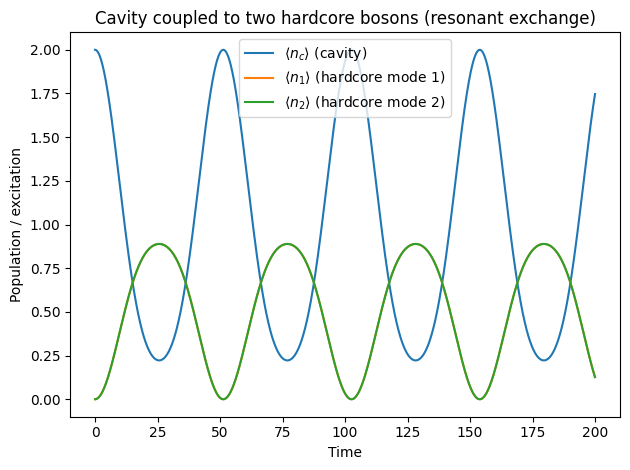

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# ----------------------------
# Parameters
# ----------------------------
wc = 1.0          # cavity frequency
wb = 1.0          # hardcore-boson frequency (resonant: wb = wc)
g  = 0.05        # coupling strength

Nc = 3            # cavity truncation: |0>,|1>,|2> (max 2 photons)
Nb = 2            # hardcore boson: |0>,|1> only

t_max = 200
num_t = 2000
tlist = np.linspace(0, t_max, num_t)

# ----------------------------
# Operators on H = cavity ⊗ b1 ⊗ b2
# ----------------------------
a  = tensor(destroy(Nc), qeye(Nb), qeye(Nb))
nc = a.dag() * a

b1 = tensor(qeye(Nc), destroy(Nb), qeye(Nb))
n1 = b1.dag() * b1

b2 = tensor(qeye(Nc), qeye(Nb), destroy(Nb))
n2 = b2.dag() * b2

# ----------------------------
# Hamiltonian: 3-mode exchange (beam-splitter) with hardcore modes
# H = wc a†a + wb (b1†b1 + b2†b2) + g [a†(b1+b2) + a(b1†+b2†)]
# ----------------------------
H_free = wc * nc + wb * (n1 + n2)
H_int  = g * (a.dag() * (b1 + b2) + a * (b1.dag() + b2.dag()))
H = H_free + H_int

# ----------------------------
# Initial state examples (pick one)
# ----------------------------

# Example A: start with 2 photons in cavity, both hardcore modes empty
psi0 = tensor(basis(Nc, 2), basis(Nb, 0), basis(Nb, 0))  # |2,0,0>

# Example B (cleaner oscillations often): 1 photon in cavity
# psi0 = tensor(basis(Nc, 1), basis(Nb, 0), basis(Nb, 0))  # |1,0,0>

# Example C: excite hardcore mode 1
# psi0 = tensor(basis(Nc, 0), basis(Nb, 1), basis(Nb, 0))  # |0,1,0>

# No dissipation (pure coherent exchange)
c_ops = []

# Evolve and record populations
e_ops = [nc, n1, n2]
res = mesolve(H, psi0, tlist, c_ops, e_ops)

nc_t = np.real(res.expect[0])
n1_t = np.real(res.expect[1])
n2_t = np.real(res.expect[2])

# Optional: check total excitation conservation (should be constant in this model)
Ntot = nc + n1 + n2
Nres = mesolve(H, psi0, tlist, c_ops, [Ntot])
print("Ntot min/max:", np.min(Nres.expect[0]), np.max(Nres.expect[0]))

# ----------------------------
# Plot
# ----------------------------
plt.figure()
plt.plot(tlist, nc_t, label=r'$\langle n_c\rangle$ (cavity)')
plt.plot(tlist, n1_t, label=r'$\langle n_1\rangle$ (hardcore mode 1)')
plt.plot(tlist, n2_t, label=r'$\langle n_2\rangle$ (hardcore mode 2)')
plt.xlabel("Time")
plt.ylabel("Population / excitation")
plt.title("Cavity coupled to two hardcore bosons (resonant exchange)")
plt.legend()
plt.tight_layout()
plt.show()
